Done — train: 363, val: 65


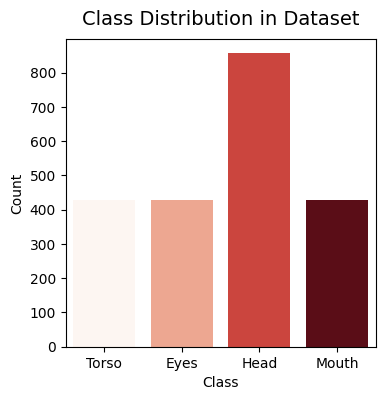

,Class,Count,Label,Percentage
0,0,428,Mouth,20.0%
1,1,428,Torso,20.0%
2,2,856,Eyes,40.0%
3,3,428,Head,20.0%


In [3]:
import os
import random
import shutil
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def split_dataset(images_src, labels_src, output_dir="data", train_ratio=0.85, seed=42):
    '''Splits dataset into train and validation sets, copying images and labels to the appropriate directories.'''

    images = [f for f in os.listdir(images_src) if f.endswith(".png")]
    random.seed(seed)
    random.shuffle(images)

    for split in ["train", "val"]:
        os.makedirs(os.path.join(output_dir, "images", split), exist_ok=True)
        os.makedirs(os.path.join(output_dir, "labels", split), exist_ok=True)

    split_idx = int(len(images) * train_ratio)
    for i, img in enumerate(images):
        label = img.replace(".png", ".txt")
        dest = "train" if i < split_idx else "val"

        shutil.copy(
            os.path.join(images_src, img), os.path.join(output_dir, "images", dest, img)
        )
        label_path = os.path.join(labels_src, label)
        if os.path.exists(label_path):
            shutil.copy(label_path, os.path.join(output_dir, "labels", dest, label))

    print(f"Done — train: {split_idx}, val: {len(images) - split_idx}")


def plot_class_distribution(
    labels_path, num_classes=4, class_names=None, palette="Reds"
):
    classes = range(num_classes)
    class_counts = {c: 0 for c in classes}

    for file in os.listdir(labels_path):
        if file.endswith(".txt"):
            with open(os.path.join(labels_path, file), "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        cls = int(parts[0])
                        if cls in class_counts:
                            class_counts[cls] += 1

    tick_labels = class_names if class_names else list(classes)
    df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
    
    plt.figure(figsize=(4, 4))
    sns.barplot(
        x="Class", y="Count", data=df, hue="Class", palette=palette, legend=False
    )
    plt.title("Class Distribution in Dataset", fontsize=14, pad=10)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(list(classes), tick_labels)
    plt.show()
    return df

split_dataset("dataset_1/images", "dataset_1/labels")
df = plot_class_distribution("dataset_1/labels", num_classes=4, class_names=["Torso", "Eyes", "Head", "Mouth"])

# More details
df["Label"] = df["Class"].map({0: "Mouth", 1: "Torso", 2: "Eyes", 3: "Head"})
df["Percentage"] = (df["Count"] / df["Count"].sum() * 100).round(2).astype(str) + "%"
df

In [27]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
True


ClearML Task: overwriting (reusing) task id=6aa6067547144d409d3985651d30ebe6
ClearML results page: https://app.clear.ml/projects/bab4f98ba6d147688fafe06e98131cbe/experiments/6aa6067547144d409d3985651d30ebe6/output/log
New https://pypi.org/project/ultralytics/8.4.26 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.25  Python-3.13.3 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0

██████████████████████████████████ 100% | 5.20/5.2 MB [00:10<00:00,  2.10s/MB]: 


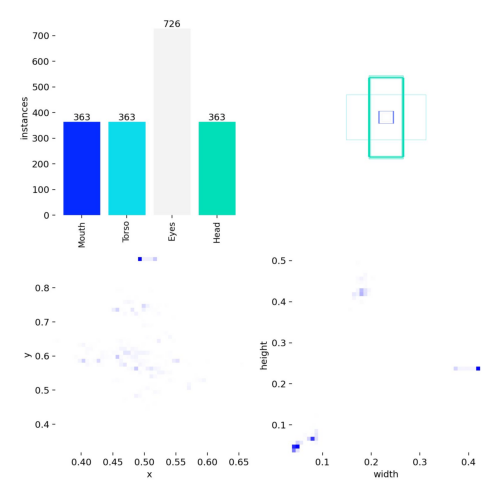

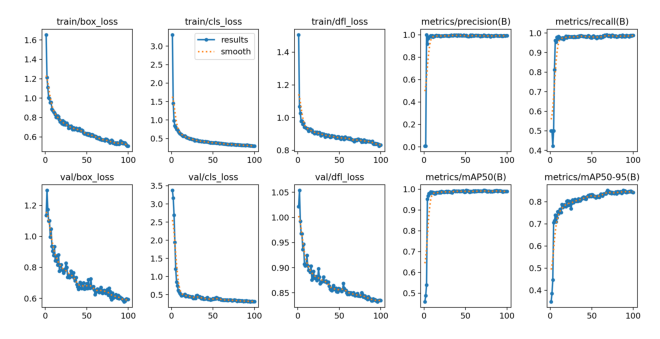

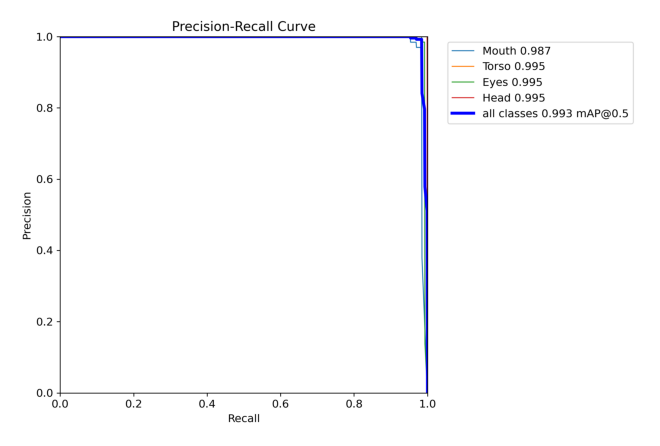

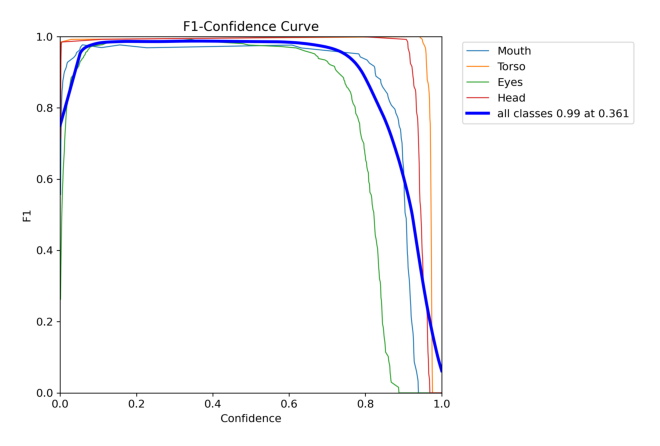

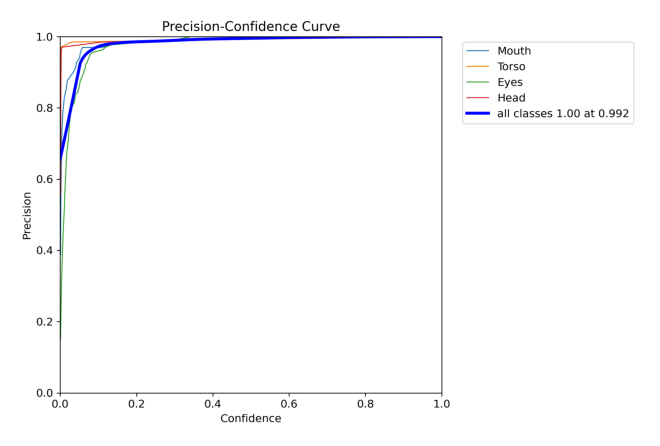

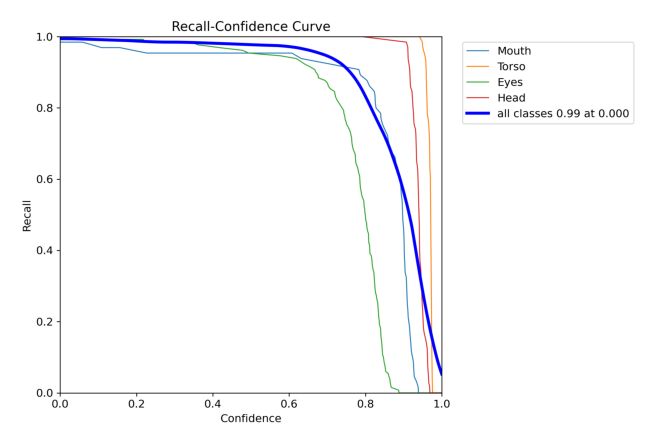

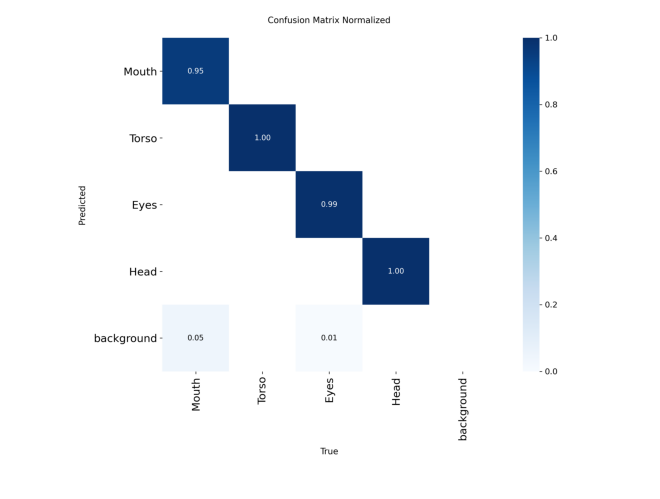

In [4]:
from ultralytics import YOLO
from clearml import Task

task = Task.init(project_name="Main", task_name="YOLO Training")

model = YOLO("yolo11n.pt")
model.train(
    data="dataset_1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="runs",
    name="fatigue-v1",
    device=0
)

task.close()

In [ ]:
import cv2
from ultralytics import YOLO

model = YOLO("./runs/detect/runs/fatigue-v15/weights/best.pt")
cap = cv2.VideoCapture(0)  # 0 = default webcam
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

while True:
    success, frame = cap.read()
    if not success:
        break

    results = model(frame)
    annotated = results[0].plot()  # draws boxes + labels on frame

    cv2.imshow("FatigueSense - Live Detection", annotated)

    if cv2.waitKey(1) & 0xFF == ord("q"):  # press Q to quit
        break

cap.release()
cv2.destroyAllWindows()


0: 384x640 1 Mouth, 2 Eyess, 1 Head, 85.7ms
Speed: 3.7ms preprocess, 85.7ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Mouth, 2 Eyess, 1 Head, 25.3ms
Speed: 4.3ms preprocess, 25.3ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Mouth, 2 Eyess, 1 Head, 30.3ms
Speed: 3.5ms preprocess, 30.3ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Mouth, 2 Eyess, 1 Head, 31.9ms
Speed: 3.7ms preprocess, 31.9ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Mouth, 2 Eyess, 1 Head, 30.2ms
Speed: 3.0ms preprocess, 30.2ms inference, 4.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Mouth, 2 Eyess, 1 Head, 31.4ms
Speed: 2.4ms preprocess, 31.4ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Mouth, 2 Eyess, 1 Head, 19.8ms
Speed: 1.7ms preprocess, 19.8ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 38

KeyboardInterrupt: 

: 